# AIO2026 CONQUER MODULE 1
## Similarity Matching Methods for Images and Texts

In [1]:
# Install and setup dependencies
!pip install datasets transformers scikit-learn matplotlib pandas torch torchvision

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from transformers import CLIPProcessor, CLIPModel
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Add seeds to make random negatives and qualitative demos reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### 1. Google Drive Mounting

In [2]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
    SAVE_DIR = "/content/drive/MyDrive/AIO2026_Conquer_Module01"
    os.makedirs(SAVE_DIR, exist_ok=True)
except ImportError:
    SAVE_DIR = "./"

# Device configuration (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device('cpu')

Mounted at /content/drive


### 2. Pure Cosine Similarity helper function

In [3]:
def cosine_sim(a, b):
    a = np.array(a, dtype=float).flatten()
    b = np.array(b, dtype=float).flatten()
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    # (1e-8) is added to prevent division by zero
    return dot_product / (norm_a * norm_b + 1e-8)

### 3. Prepare data

In [4]:
dataset = load_dataset("jxie/flickr8k")


# Helper function to grab the first valid caption
def extract_caption(item):
    for i in range(5):
        key = f"caption_{i}"
        if key in item and item[key] and len(str(item[key])) > 5:
            return item[key]
    return "A photo of something."


# load train set (6000 images)
# this train set is only for linear regression
# for finding the maping weights "W" of method 2
train_images = []
train_captions = []
for item in dataset["train"]:
    if "image" in item:
        train_images.append(item["image"].convert("RGB"))
        train_captions.append(extract_caption(item))

# load test set (1000 images)
test_images = []
test_captions = []
for item in dataset["test"]:
    if "image" in item:
        test_images.append(item["image"].convert("RGB"))
        test_captions.append(extract_caption(item))

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

### 4. Feature extraction

In [5]:
# 1. ResNet50 for Image Features
resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
# Remove the final classification layer (fc) to get the raw 2048-dim feature vector
resnet.fc = torch.nn.Identity()
resnet = resnet.to(device).eval()

resnet_transforms = T.Compose(
    [
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


# Helper function to extract ResNet features (batch)
def extract_resnet_features(image_list, batch_size=64):
    features = []
    with torch.no_grad():
        for start in range(0, len(image_list), batch_size):
            batch = image_list[start : start + batch_size]
            batch_tensor = torch.stack([resnet_transforms(img) for img in batch])
            batch_tensor = batch_tensor.to(device)
            features.append(resnet(batch_tensor).cpu().numpy())
    return np.concatenate(features, axis=0)


# Extract ResNet for both Train and Test sets
train_resnet_features = extract_resnet_features(train_images)
test_resnet_features = extract_resnet_features(test_images)

# 2. TF-IDF for Text Features
vectorizer = TfidfVectorizer(max_features=500)
# IMPORTANT! FIT on train to build vocab, but only TRANSFORM test
train_tfidf_features = vectorizer.fit_transform(train_captions).toarray()
test_tfidf_features = vectorizer.transform(test_captions).toarray()

# 3. Clip for both modalities
clip_model_id = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device).eval()


# Helper function to extract CLIP features (batch)
def extract_clip_features(image_list, caption_list, batch_size=32):
    img_features = []
    txt_features = []
    with torch.no_grad():
        for start in range(0, len(image_list), batch_size):
            img_batch = image_list[start : start + batch_size]
            cap_batch = caption_list[start : start + batch_size]
            inputs = clip_processor(
                text=cap_batch,
                images=img_batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
            ).to(device)
            outputs = clip_model(**inputs)

            # Normalie CLIP embeddings
            img_emb = outputs.image_embeds
            img_emb = img_emb / (img_emb.norm(dim=-1, keepdim=True) + 1e-8)

            txt_emb = outputs.text_embeds
            txt_emb = txt_emb / (txt_emb.norm(dim=-1, keepdim=True) + 1e-8)

            img_features.append(img_emb.cpu().numpy())
            txt_features.append(txt_emb.cpu().numpy())
    return np.concatenate(img_features, axis=0), np.concatenate(txt_features, axis=0)


# Extract for both Train and Test sets
train_clip_img_features, train_clip_txt_features = extract_clip_features(
    train_images, train_captions
)
test_clip_img_features, test_clip_txt_features = extract_clip_features(
    test_images, test_captions
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:10<00:00, 9.34MB/s]


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

### 5. Train Linear Regression for projecting the visual space into the textual space (Method 2)

In [6]:
lin_reg = LinearRegression()
lin_reg.fit(
    train_resnet_features, train_tfidf_features
)  # Finding the mapping weights "W"

projected_test_resnet_features = lin_reg.predict(test_resnet_features)

### 6. Make hard negative helper function

In [7]:
def make_hard_negative(text):
    """
    Modifies the caption by swapping key subjects to create a conceptually
    different sentence (a 'hard negative').
    """
    words = text.split()
    replacements = {
        # Animals
        "dog": "cat",
        "Dog": "Cat",
        "cat": "dog",
        "Cat": "Dog",
        "puppy": "kitten",
        "Puppy": "Kitten",
        "kitten": "puppy",
        "Kitten": "Puppy",
        # People (Gender)
        "man": "woman",
        "Man": "Woman",
        "woman": "man",
        "Woman": "Man",
        "boy": "girl",
        "Boy": "Girl",
        "girl": "boy",
        "Girl": "Boy",
        "male": "female",
        "Male": "Female",
        "female": "male",
        "Female": "Male",
        # Familial Relationships
        "father": "mother",
        "Father": "Mother",
        "mother": "father",
        "Mother": "Father",
        "son": "daughter",
        "Son": "Daughter",
        "daughter": "son",
        "Daughter": "Son",
        "husband": "wife",
        "Husband": "Wife",
        "wife": "husband",
        "Wife": "Husband",
        "brother": "sister",
        "Brother": "Sister",
        "sister": "brother",
        "Sister": "Brother",
        "grandfather": "grandmother",
        "Grandfather": "Grandmother",
        "grandmother": "grandfather",
        "Grandmother": "Grandfather",
        "grandson": "granddaughter",
        "Grandson": "Granddaughter",
        "granddaughter": "grandson",
        "Granddaughter": "Grandson",
        "uncle": "aunt",
        "Uncle": "Aunt",
        "aunt": "uncle",
        "Aunt": "Uncle",
        "nephew": "niece",
        "Nephew": "Niece",
        "niece": "nephew",
        "Niece": "Nephew",
        # Pronouns
        "he": "she",
        "He": "She",
        "she": "he",
        "She": "He",
        "him": "her",
        "Him": "Her",
        "her": "him",
        "Her": "Him",
        "his": "her",
        "His": "Her",
        "himself": "herself",
        "Himself": "Herself",
        "herself": "himself",
        "Herself": "Himself",
        # Professions & Titles
        "actor": "actress",
        "Actor": "Actress",
        "actress": "actor",
        "Actress": "Actor",
        "waiter": "waitress",
        "Waiter": "Waitress",
        "waitress": "waiter",
        "Waitress": "Waiter",
        "king": "queen",
        "King": "Queen",
        "queen": "king",
        "Queen": "King",
        "prince": "princess",
        "Prince": "Princess",
        "princess": "prince",
        "Princess": "Prince",
        # Actions/Verbs
        "running": "standing",
        "Running": "Standing",
        "standing": "running",
        "Standing": "Running",
        "walking": "sitting",
        "Walking": "Sitting",
        "sitting": "walking",
        "Sitting": "Walking",
        "jumping": "sleeping",
        "Jumping": "Sleeping",
        # Locations
        "beach": "street",
        "Beach": "Street",
        "street": "beach",
        "Street": "Beach",
        "grass": "pavement",
        "Grass": "Pavement",
        "field": "room",
        "Field": "Room",
        # Counts
        "one": "two",
        "One": "Two",
        "two": "one",
        "Two": "One",
        "group": "individual",
        "Group": "Individual",
    }
    new_words = []
    modified = False
    for w in words:
        clean_w = w.strip(".,!?\"'")
        if clean_w in replacements:
            new_words.append(w.replace(clean_w, replacements[clean_w]))
            modified = True
        else:
            new_words.append(w)
    return " ".join(new_words), modified

### 7. Evaluate

In [8]:
def calculate_retrieval_metrics(img_features, txt_features):
    num_samples = len(img_features)
    img_norm = img_features / (
        np.linalg.norm(img_features, axis=1, keepdims=True) + 1e-8
    )
    txt_norm = txt_features / (
        np.linalg.norm(txt_features, axis=1, keepdims=True) + 1e-8
    )

    sim_matrix = np.dot(img_norm, txt_norm.T)

    # Indices sort DESC of sims
    sorted_indices = np.argsort(sim_matrix, axis=1)[:, ::-1]

    # Find the rank of the ground truth (the diagonal where j == i)
    ground_truth_positions = np.arange(num_samples).reshape(num_samples, 1)
    ranks = np.where(sorted_indices == ground_truth_positions)[1] + 1

    recall_at_1 = np.sum(ranks == 1) / num_samples
    recall_at_5 = np.sum(ranks <= 5) / num_samples
    mrr = np.sum(1.0 / ranks) / num_samples

    return {
        "R@1": recall_at_1,
        "R@5": recall_at_5,
        "MRR": mrr,
    }


results = {
    "Method 1 (Naive Baseline)": {"pos": [], "rand": [], "hard": []},
    "Method 2 (Linear Projection)": {"pos": [], "rand": [], "hard": []},
    "Method 3 (CLIP)": {"pos": [], "rand": [], "hard": []},
}

tfidf_dim = train_tfidf_features.shape[1]
m1_test_img_features = test_resnet_features[:, :tfidf_dim]

print("Calculating cosine similarity scores...")
# Loop over the TEST set only
for i in range(len(test_images)):
    m1_img = m1_test_img_features[i]
    m1_txt = test_tfidf_features[i]

    # m2 uses the model projected on the test set
    m2_img = projected_test_resnet_features[i]
    m2_txt = test_tfidf_features[i]

    m3_img = test_clip_img_features[i]
    m3_txt = test_clip_txt_features[i]

    # 1. Positive Pair
    results["Method 1 (Naive Baseline)"]["pos"].append(cosine_sim(m1_img, m1_txt))
    results["Method 2 (Linear Projection)"]["pos"].append(cosine_sim(m2_img, m2_txt))
    results["Method 3 (CLIP)"]["pos"].append(cosine_sim(m3_img, m3_txt))

    # 2. Random Negative Pair
    j = random.choice([x for x in range(len(test_images)) if x != i])
    results["Method 1 (Naive Baseline)"]["rand"].append(
        cosine_sim(m1_img, test_tfidf_features[j])
    )
    results["Method 2 (Linear Projection)"]["rand"].append(
        cosine_sim(m2_img, test_tfidf_features[j])
    )
    results["Method 3 (CLIP)"]["rand"].append(
        cosine_sim(m3_img, test_clip_txt_features[j])
    )

    # 3. Hard Negative
    hard_cap, was_modified = make_hard_negative(test_captions[i])
    if was_modified:
        m12_hard_txt = vectorizer.transform([hard_cap]).toarray()[0]

        with torch.no_grad():
            inputs = clip_processor(
                text=[hard_cap],
                images=[test_images[i]],
                return_tensors="pt",
                padding=True,
            ).to(device)
            outputs = clip_model(**inputs)
            m3_hard_txt = outputs.text_embeds.cpu().numpy().flatten()

        results["Method 1 (Naive Baseline)"]["hard"].append(
            cosine_sim(m1_img, m12_hard_txt)
        )
        results["Method 2 (Linear Projection)"]["hard"].append(
            cosine_sim(m2_img, m12_hard_txt)
        )
        results["Method 3 (CLIP)"]["hard"].append(cosine_sim(m3_img, m3_hard_txt))

print("Calculating Retrieval Metrics (Recall/MRR)...")
retrieval_metrics = {
    "Method 1 (Naive Baseline)": calculate_retrieval_metrics(
        m1_test_img_features, test_tfidf_features
    ),
    "Method 2 (Linear Projection)": calculate_retrieval_metrics(
        projected_test_resnet_features, test_tfidf_features
    ),
    "Method 3 (CLIP)": calculate_retrieval_metrics(
        test_clip_img_features, test_clip_txt_features
    ),
}

Calculating cosine similarity scores...
Calculating Retrieval Metrics (Recall/MRR)...


### 8. Format and save results to table

In [9]:
table_data = []
for method in results.keys():
    pos_mean, pos_std = np.mean(results[method]["pos"]), np.std(results[method]["pos"])
    rand_mean, rand_std = (
        np.mean(results[method]["rand"]),
        np.std(results[method]["rand"]),
    )

    if len(results[method]["hard"]) > 0:
        hard_mean, hard_std = (
            np.mean(results[method]["hard"]),
            np.std(results[method]["hard"]),
        )
    else:
        hard_mean, hard_std = 0.0, 0.0

    ret = retrieval_metrics[method]

    table_data.append(
        {
            "Method": method,
            "Positive Pair": f"{pos_mean:.4f} ± {pos_std:.4f}",
            "Random Negative": f"{rand_mean:.4f} ± {rand_std:.4f}",
            "Hard Negative": f"{hard_mean:.4f} ± {hard_std:.4f}",
            "R@1": f"{ret['R@1']:.4f}",
            "R@5": f"{ret['R@5']:.4f}",
            "MRR": f"{ret['MRR']:.4f}",
        }
    )

df_results = pd.DataFrame(table_data)

print("\nFinal Benchmark Comparison Table")
print("=" * 113)
print(df_results.to_markdown(index=False))
print("=" * 113)

csv_path = os.path.join(SAVE_DIR, "results.csv")
df_results.to_csv(csv_path, index=False)


Final Benchmark Comparison Table
| Method                       | Positive Pair   | Random Negative   | Hard Negative   |   R@1 |   R@5 |    MRR |
|:-----------------------------|:----------------|:------------------|:----------------|------:|------:|-------:|
| Method 1 (Naive Baseline)    | 0.0340 ± 0.0434 | 0.0388 ± 0.0464   | 0.0329 ± 0.0435 | 0.002 | 0.005 | 0.0075 |
| Method 2 (Linear Projection) | 0.2016 ± 0.1307 | 0.0604 ± 0.0746   | 0.1635 ± 0.1145 | 0.055 | 0.17  | 0.119  |
| Method 3 (CLIP)              | 0.3184 ± 0.0324 | 0.1704 ± 0.0452   | 0.2876 ± 0.0406 | 0.55  | 0.832 | 0.6736 |


### 9. Similarity Score Distribution

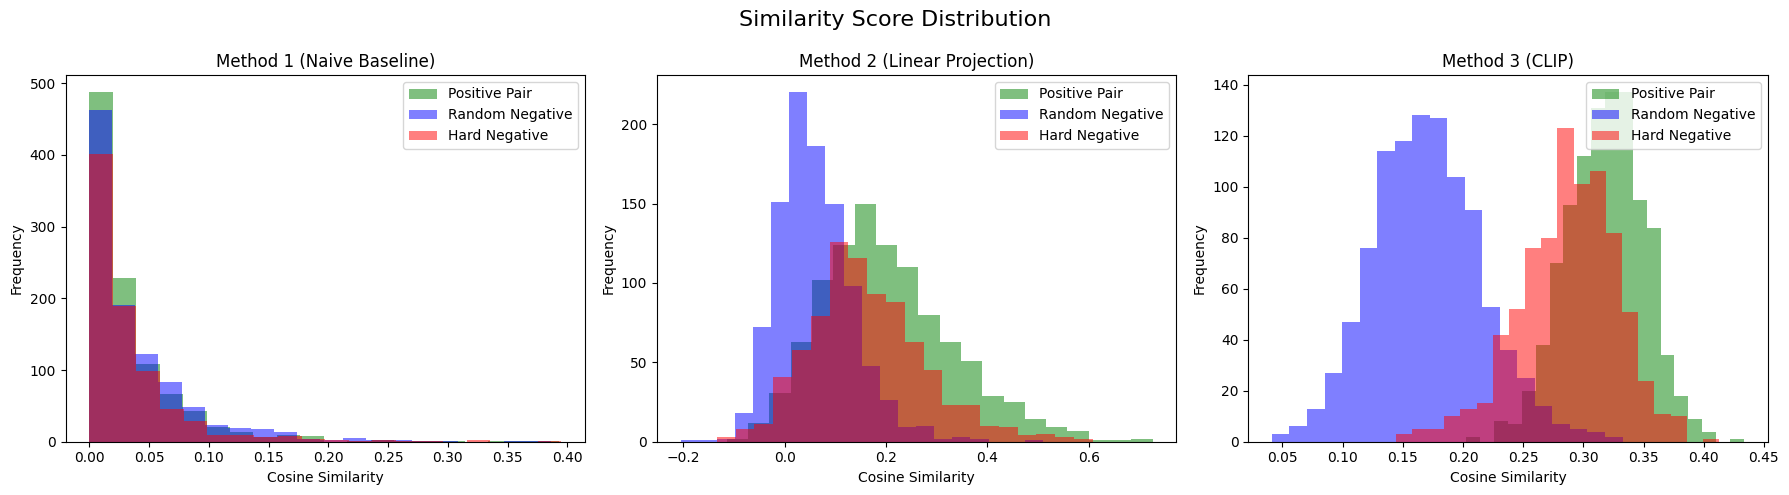

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods = list(results.keys())

for idx, method in enumerate(methods):
    ax = axes[idx]

    # Plot histograms
    ax.hist(
        results[method]["pos"], bins=20, alpha=0.5, label="Positive Pair", color="green"
    )
    ax.hist(
        results[method]["rand"],
        bins=20,
        alpha=0.5,
        label="Random Negative",
        color="blue",
    )

    if len(results[method]["hard"]) > 0:
        ax.hist(
            results[method]["hard"],
            bins=20,
            alpha=0.5,
            label="Hard Negative",
            color="red",
        )

    ax.set_title(method)
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Similarity Score Distribution", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

### 10. CLIP Similarity Heatmap

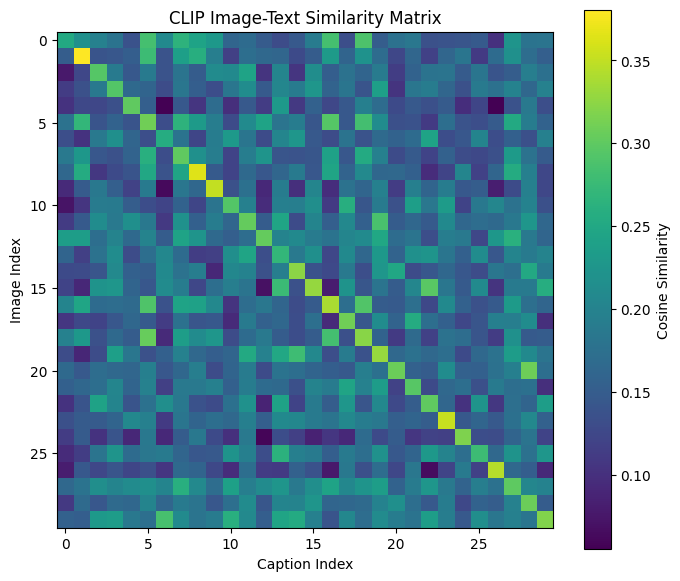

In [11]:
heatmap_size = 30

similarity_matrix = np.zeros((heatmap_size, heatmap_size))

for i in range(heatmap_size):
    for j in range(heatmap_size):
        similarity_matrix[i, j] = cosine_sim(
            test_clip_img_features[i], test_clip_txt_features[j]
        )

plt.figure(figsize=(8, 7))

plt.imshow(similarity_matrix, cmap="viridis")

plt.colorbar(label="Cosine Similarity")

plt.xlabel("Caption Index")
plt.ylabel("Image Index")

plt.title("CLIP Image-Text Similarity Matrix")

plt.show()

### 11. Top-K Retrieval Qualitative Demo


TOP-K RETRIEVAL QUALITATIVE DEMO (CLIP MODEL - TEST SET)

Query Image Index: 615
Ground Truth Caption:
"a group of woman in pink dresses walking across a crosswalk towards a cruisship ."


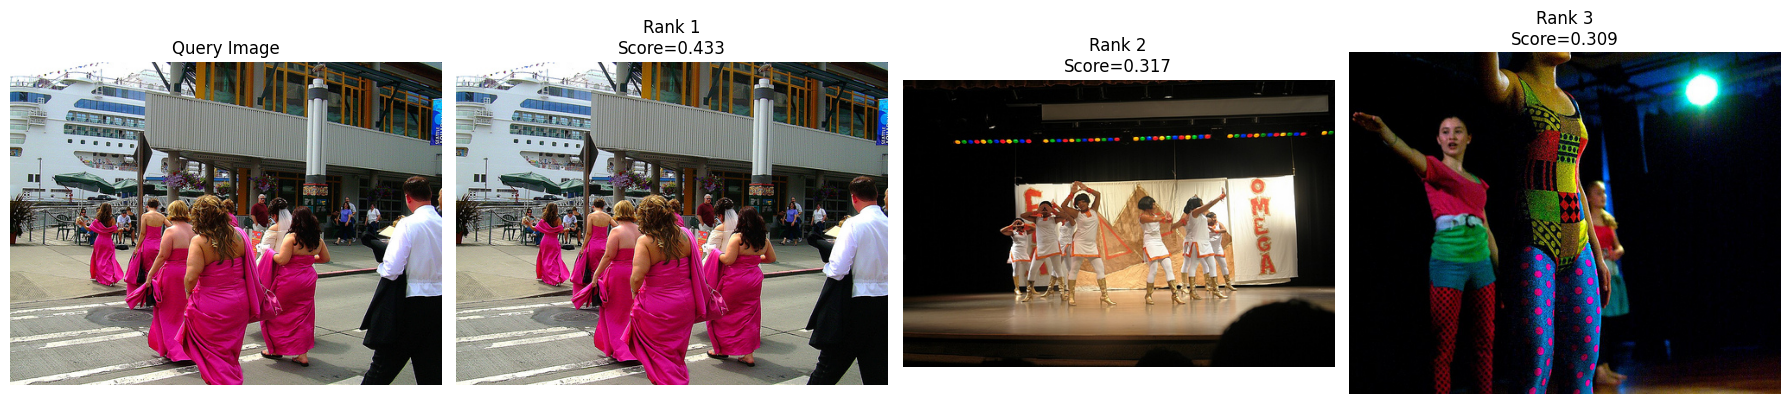


Top 3 Retrieved Captions
1. Score=0.4334
   a group of woman in pink dresses walking across a crosswalk towards a cruisship .
2. Score=0.3172
   A group of women are performing onstage .
3. Score=0.3091
   Girls dance in colorful outfits .
------------------------------------------------------------------------------------------

Query Image Index: 779
Ground Truth Caption:
"A man does a trick on his skateboard in front of a crowd ."


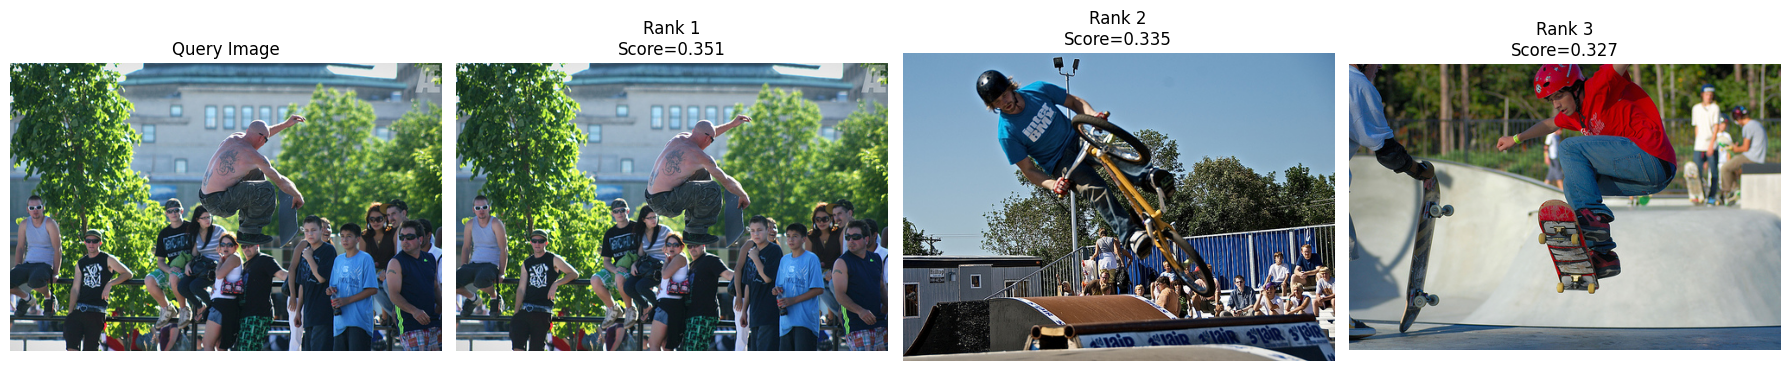


Top 3 Retrieved Captions
1. Score=0.3510
   A man does a trick on his skateboard in front of a crowd .
2. Score=0.3347
   A man is doing tricks on a bicycle on ramps in front of a crowd .
3. Score=0.3275
   A man wearing a red helmet jumps up while riding a skateboard .
------------------------------------------------------------------------------------------


In [12]:
print("=" * 90)
print("TOP-K RETRIEVAL QUALITATIVE DEMO (CLIP MODEL - TEST SET)")
print("=" * 90)

num_test = len(test_images)

# Best retrieval example
best_idx = np.argmax(results["Method 3 (CLIP)"]["pos"])

# Random example
random_idx = random.randint(0, num_test - 1)

demo_indices = [best_idx, random_idx]

for idx in demo_indices:
    img_feat = test_clip_img_features[idx]

    # Compute cosine similarities
    sims = []

    for j in range(num_test):
        score = cosine_sim(img_feat, test_clip_txt_features[j])
        sims.append((j, score))

    sims.sort(key=lambda x: x[1], reverse=True)

    # Text output

    print(f"\nQuery Image Index: {idx}")
    print(f'Ground Truth Caption:\n"{test_captions[idx]}"')

    # Visualization

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    # Query image
    axes[0].imshow(test_images[idx])
    axes[0].set_title("Query Image")
    axes[0].axis("off")

    # Top-3 retrieved captions/images
    for k, (j, score) in enumerate(sims[:3]):
        axes[k + 1].imshow(test_images[j])

        axes[k + 1].set_title(f"Rank {k + 1}\nScore={score:.3f}")

        axes[k + 1].set_xlabel(test_captions[j], fontsize=8)

        axes[k + 1].axis("off")

    plt.tight_layout()
    plt.show()

    # Also print captions

    print("\nTop 3 Retrieved Captions")

    for rank, (j, score) in enumerate(sims[:3]):
        print(f"{rank + 1}. Score={score:.4f}\n   {test_captions[j]}")

    print("-" * 90)

### 12. Error Analysis (Failure Cases)

ERROR ANALYSIS (CLIP MODEL)

Query Image Index (Failure Case): 0
Ground Truth Caption (Rank 118):
"The dogs are in the snow in front of a fence ."

Top 3 Retrieved Captions (Incorrectly ranked higher):
1. Score=0.3664 
   Two Dobermans fighting or playing together on a lawn .
2. Score=0.3364 
   A black and a blonde dog are either playing or fighting with each other .
3. Score=0.3292 
   A black dog and a tan dog fighting .


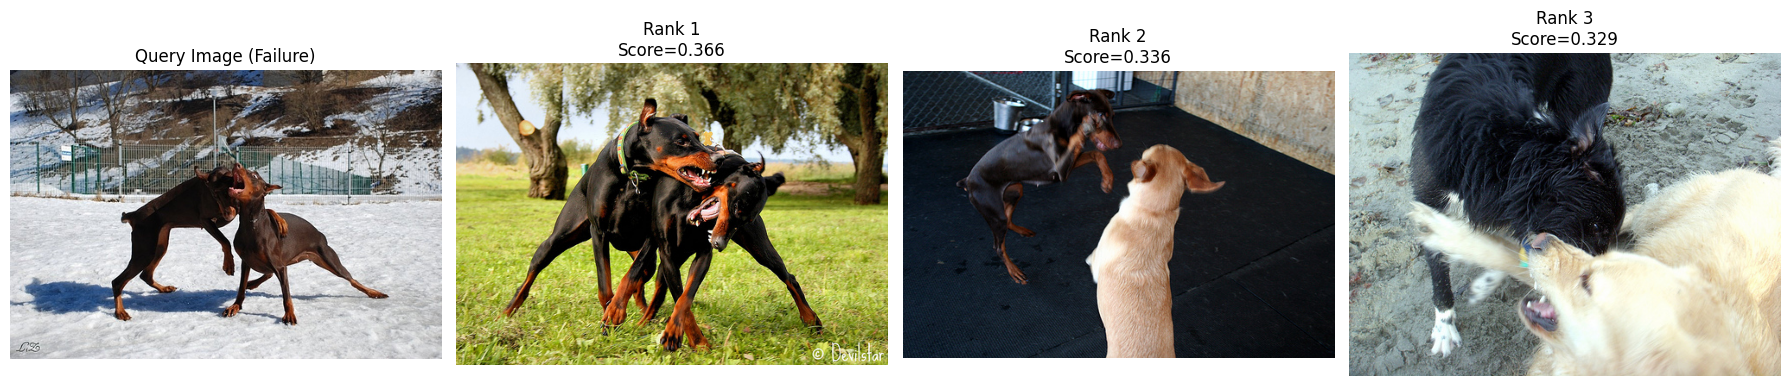

------------------------------------------------------------------------------------------


In [13]:
print("=" * 90)
print("ERROR ANALYSIS (CLIP MODEL)")
print("=" * 90)

# Find a case where rank > 1
failure_idx = -1
for i in range(num_test):
    img_feat = test_clip_img_features[i]
    sims = []
    for j in range(num_test):
        sims.append((j, cosine_sim(img_feat, test_clip_txt_features[j])))
    sims.sort(key=lambda x: x[1], reverse=True)
    rank = 0
    for r, (j, score) in enumerate(sims):
        if j == i:
            rank = r + 1
            break
    if rank > 3:  # Find a tough one
        failure_idx = i
        break

if failure_idx != -1:
    print(f"\nQuery Image Index (Failure Case): {failure_idx}")
    print(f'Ground Truth Caption (Rank {rank}):\n"{test_captions[failure_idx]}"')

    img_feat = test_clip_img_features[failure_idx]
    sims = []
    for j in range(num_test):
        sims.append((j, cosine_sim(img_feat, test_clip_txt_features[j])))
    sims.sort(key=lambda x: x[1], reverse=True)

    print("\nTop 3 Retrieved Captions (Incorrectly ranked higher):")
    for r, (j, score) in enumerate(sims[:3]):
        print(f"{r + 1}. Score={score:.4f} \n   {test_captions[j]}")

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(test_images[failure_idx])
    axes[0].set_title("Query Image (Failure)")
    axes[0].axis("off")

    for k, (j, score) in enumerate(sims[:3]):
        axes[k + 1].imshow(test_images[j])
        axes[k + 1].set_title(f"Rank {k + 1}\nScore={score:.3f}")
        axes[k + 1].set_xlabel(
            test_captions[j][:50] + "...", fontsize=8
        )  # truncated for visual
        axes[k + 1].axis("off")
    plt.tight_layout()
    plt.show()

print("-" * 90)

### 13. Ablation Study: TF-IDF Vocabulary Size

In [14]:
print("=" * 90)
print("ABLATION STUDY: TF-IDF VOCABULARY SIZE")
print("=" * 90)

vocab_sizes = [500, 1000, 2000]
ablation_results = []

for vs in vocab_sizes:
    print(f"Testing vocab size: {vs}...")
    vec = TfidfVectorizer(max_features=vs)
    tr_tfidf = vec.fit_transform(train_captions).toarray()
    te_tfidf = vec.transform(test_captions).toarray()

    lin_r = LinearRegression()
    lin_r.fit(train_resnet_features, tr_tfidf)
    proj_te_resnet = lin_r.predict(test_resnet_features)

    ret_metrics = calculate_retrieval_metrics(proj_te_resnet, te_tfidf)
    ablation_results.append(
        {
            "Vocab Size": vs,
            "Recall@1": f"{ret_metrics['R@1']:.4f}",
            "Recall@5": f"{ret_metrics['R@5']:.4f}",
            "MRR": f"{ret_metrics['MRR']:.4f}",
        }
    )

df_ablation = pd.DataFrame(ablation_results)
print("\nAblation Results (Method 2 - Linear Projection):")
print(df_ablation.to_markdown(index=False))

ABLATION STUDY: TF-IDF VOCABULARY SIZE
Testing vocab size: 500...
Testing vocab size: 1000...
Testing vocab size: 2000...

Ablation Results (Method 2 - Linear Projection):
|   Vocab Size |   Recall@1 |   Recall@5 |    MRR |
|-------------:|-----------:|-----------:|-------:|
|          500 |      0.055 |      0.17  | 0.119  |
|         1000 |      0.056 |      0.193 | 0.1317 |
|         2000 |      0.055 |      0.198 | 0.1317 |
